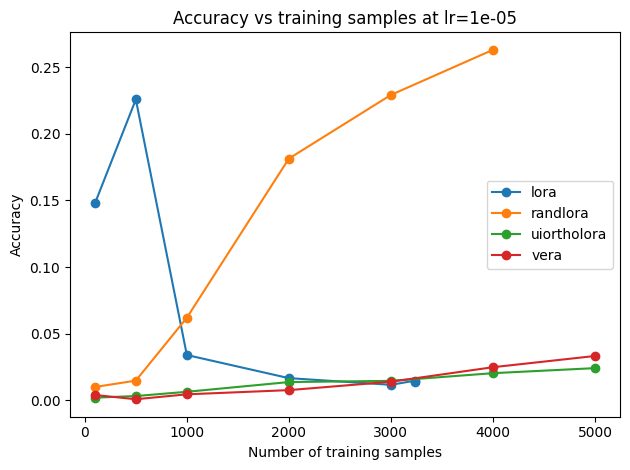

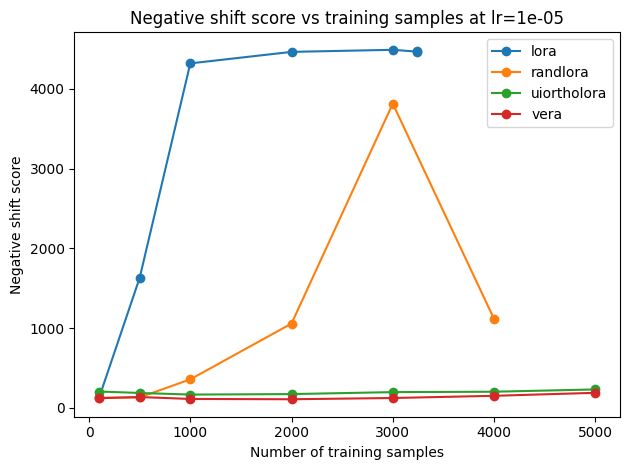

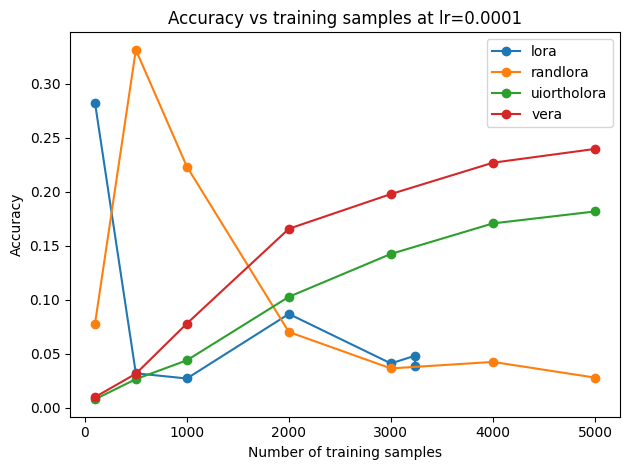

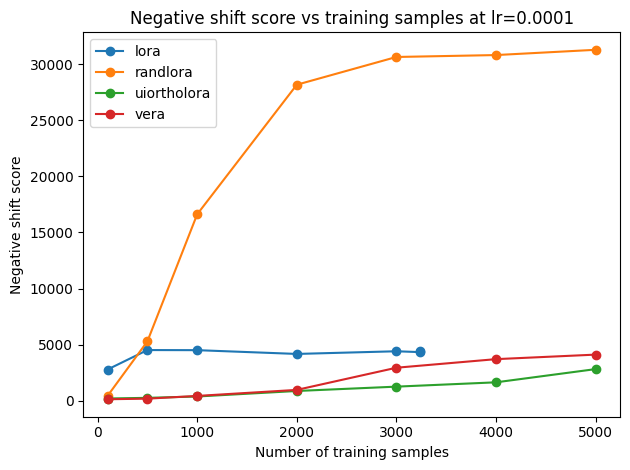

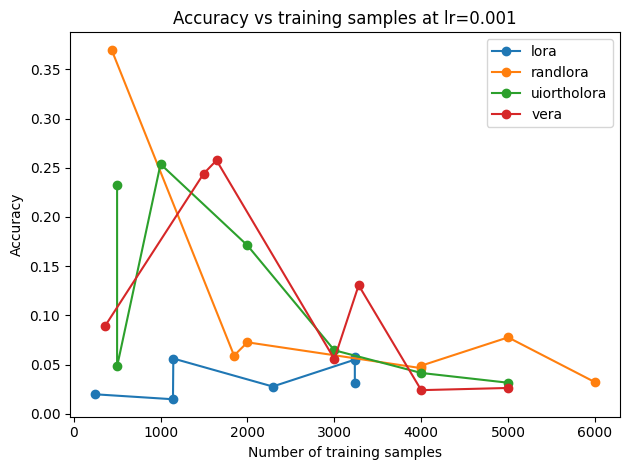

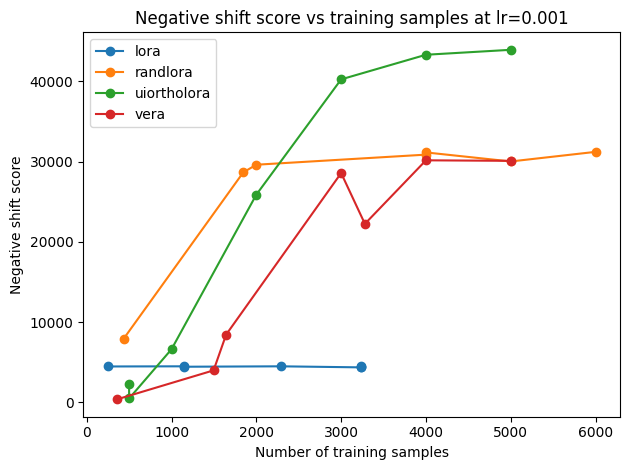

In [4]:
import io, textwrap
import pandas as pd
import matplotlib.pyplot as plt

csv_text = "adapter_results.csv"
df = pd.read_csv(csv_text)

for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
            "negative_shift_count", "negative_shift_score",
            "positive_shift_count", "positive_shift_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])

lrs = sorted(df["lr"].dropna().unique())
adapters = df["adapter_type"].unique()

def plot_metric_for_lr(lr, metric, ylabel):
    sub = df[df["lr"] == lr].copy().sort_values("train_samples")
    plt.figure()
    for adapter in adapters:
        sub_ad = sub[sub["adapter_type"] == adapter]
        if sub_ad.empty:
            continue
        plt.plot(sub_ad["train_samples"], sub_ad[metric],
                 marker="o", label=adapter)
    plt.xlabel("Number of training samples")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs training samples at lr={lr}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for lr in lrs:
    plot_metric_for_lr(lr, "accuracy", "Accuracy")
    plot_metric_for_lr(lr, "negative_shift_score", "Negative shift score")
